In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import  scipy
import pickle
import matplotlib.pyplot as plt
import sys
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
sys.path.append("../") 
import WRFDomainLib
plt.rcParams["font.family"] = "Sans-Serif"


def cmap_white(vmin=-1, vmax=6, cmap='plasma_r'):
    # Number of discrete levels
    n_levels = (vmax - vmin) + 1

    # Get reversed plasma colormap with discrete steps
    inferno = cm.get_cmap(cmap, n_levels)

    # Sample discrete colors
    colors = [inferno(i / (n_levels - 1)) for i in range(n_levels)]

    ## Replace the first color with white
    #colors[0] = (1, 1, 1, 1)  # RGBA for white

    # Create a discrete colormap
    return mcolors.ListedColormap(colors, name="cmap_white")

#cmap = plasma_white()#inferno_white()


mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)




ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed


In [3]:
def loadseason(season,path0,period,mytype):
    if mytype=='warm_dry' or mytype=='cold_dry':
        file0=path0+f'CanESM2-WRF-'+mytype+'_'+period+'_'+season.lower()+'_yearly_lte.nc'
        print(file0)
    else:
        file0=path0+f''+mytype+'_'+period+'_'+season.lower()+'_yearly.nc'

        

    #file0=path0+f''+mytype+'_'+period+'_'+season.lower()+'_yearly.nc'
    ds = xr.open_dataset(file0)
    counts = ds["count"].values
    lat = ds["lat"].values
    lon=ds['lon'].values
    return counts, lat, lon
   

In [4]:
#types=['colddry', 'warmdry', 'warmwet', 'coldwet']

seasons= ["DJF", "MAM", "JJA", "SON"];
path0='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/'
def loadandsort(mytype):
    season_data={}
    for season in seasons:
        data,lat,lon=loadseason(season,path0, 'hist', mytype)
        season_data[season] = data
    
    season_data_rcp45={}
    for season in seasons:
        data, lat, lon=loadseason(season,path0, 'rcp45', mytype)
        season_data_rcp45[season] = data
    data={}
    for season in seasons:
        data[season]=np.mean(season_data[season], axis=0)
        data['pval_'+season]= scipy.stats.ttest_ind(season_data[season], season_data_rcp45[season])[1]
        data['F_'+season]=np.mean(season_data_rcp45[season], axis=0)
    return data, lat, lon

In [5]:
colddry, lat, lon=loadandsort('cold_dry')

/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_hist_djf_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_hist_mam_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_hist_jja_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_hist_son_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_rcp45_djf_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_rcp45_mam_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_rcp45_jja_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-cold_dry_rcp45_son_yearly_lte.nc


In [6]:
warmdry, lat, lon=loadandsort('warm_dry')
coldwet, lat, lon=loadandsort('cold_wet')
warmwet, lat, lon=loadandsort('warm_wet')

/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_hist_djf_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_hist_mam_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_hist_jja_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_hist_son_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_rcp45_djf_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_rcp45_mam_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_rcp45_jja_yearly_lte.nc
/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/CanESM2-WRF-warm_dry_rcp45_son_yearly_lte.nc


In [7]:
print(len(colddry['pval_'+'DJF']))

300


In [8]:

#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons(j, count, season_data, axes, seasons, nmodels, var):
#j=0
#count=0
    vmin=vlims[var][0];vmax=vlims[var][1]
    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=var_cmaps[var], vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=[hatch_pattern],  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        
        count+=1

    if i == len(seasons) - 1:  # After last row in the column
        # Get position of the bottom axis in the column
        bbox = ax.get_position()
        # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.015         # same width, small height
        ])
        cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label(label[var], fontsize=10)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
    return count

In [9]:
def plotdata(data, val):
    #print('val n funct', val)
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
    coastline = cf.COASTLINE.with_scale('10m')
    ax.add_feature(coastline, linewidth=0.1, edgecolor='black')
    if j == 0:  # historical
        field = data[row_labels[i]]
        cmap='Blues'
        vmin=0;vmax=12
    else:
        field = data['F_'+row_labels[i]]
        mask = data['pval_'+row_labels[i]] <0.1
        cmap='PRGn'
        vmin=-val; vmax=val 
        
                
        cs = ax.contourf(
            lon, lat, ~mask,
            levels=[0.1,1],
            colors="none", 
            hatches=['...'],  # pass as a list
            transform=ccrs.PlateCarree(), zorder=10
        )
        
      
    mesh = ax.pcolormesh(
    lon, lat, field,
    cmap=cmap ,
    vmin=vmin,vmax=vmax,
    transform=ccrs.PlateCarree()    )

   
    
    #else:       # mid-century - historical
     #   diff = data_mid[i, j] - data_hist[i, j]
      #  im = ax.pcolormesh(Lon, Lat, diff,
       #                    cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff,
        #                   transform=ccrs.PlateCarree())
    
    # Hide tick labels for clarity
    ax.set_xticks([])
    ax.set_yticks([])
    if i==1:
        bbox = ax.get_position()
    # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.01         # same width, small height
        ])
        cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label(labels[j], fontsize=8)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
#plt.tight_layout()

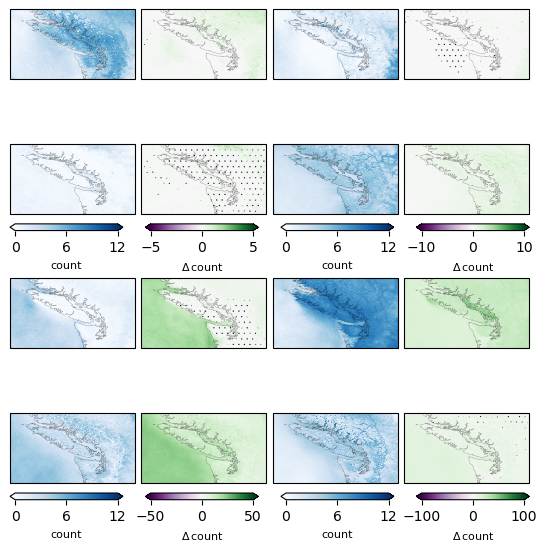

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(6.7,6.7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

col_titles = ["Historical", "Mid-Century"]
row_labels = ["JJA", "DJF"]

vvals={'coldwet': 5, 'warmwet':50, 'warmdry': 100, 'colddry':10}
labels=['count', r'$\Delta\, \mathrm{count}$']
for i in range(2):          # seasons: JJA, DJF
    for j in range(2):
        ax = axes[i, j]   # careful indexing
        var='coldwet'
        data = eval(var)
        val=vvals[var];
        #print(val)
        plotdata(data, val)
        var='warmwet'
        data = eval(var)
        val=vvals[var];

        ax=axes[i+2,j]
        plotdata(data, val)
        
        var='warmdry'
        data = eval(var)
        val=vvals[var];

        ax=axes[i+2,j+2]
        plotdata(data, val)

        var='colddry'
        data = eval(var)
        val=vvals[var];

        ax=axes[i,j+2]
        plotdata(data, val)
        
plt.subplots_adjust(hspace=0.2, wspace=0.05) 

In [11]:
def plotdata(data, val, count, var):
    #print('val n funct', val)
    data = eval(var)
    val=vvals[var];
     
    if j == 0:  # historical
        field = data[row_labels[i]]
        field[field==0]=np.nan
        cmap=cmap_white(0,countmax)#'inferno'
        vmin=0;vmax=countmax
        label0='Events/y'
        #plt.title('historical')
    else:
        field = (data['F_'+row_labels[i]]- data[row_labels[i]])/data[row_labels[i]]
        print('var,f,h,f-h, f-h/h',np.mean(data['F_'+row_labels[i]]), var, np.nanmean(data[row_labels[i]]), np.nanmean(data['F_'+row_labels[i]]- data[row_labels[i]]), np.mean(data['F_'+row_labels[i]]-np.nanmean(data[row_labels[i]]))/ np.nanmean(data[row_labels[i]]))
        mask = data['pval_'+row_labels[i]] <0.1
        cmap=cmaps[var]
        vmin=-val; vmax=val 
        label0=r'$\Delta_r$Events/y'
        #plt.title('$\Delta$')
        
                
        cs = ax.contourf(
            lon, lat, ~mask,
            levels=[0.1,1],
            colors="none", 
            hatches=hatches,  # pass as a list
            transform=ccrs.PlateCarree(), zorder=10
        )
        
     
    mesh = ax.pcolormesh(
    lon, lat, field,
    cmap=cmap ,
    vmin=vmin,vmax=vmax,
    transform=ccrs.PlateCarree()    )

    ax.set_extent([-129.6, -120.10, 46.4, 51.7], crs=ccrs.PlateCarree())
    coastline = cf.COASTLINE.with_scale('10m')
    ax.add_feature(coastline, linewidth=0.1, edgecolor='black')
    
    #else:       # mid-century - historical
     #   diff = data_mid[i, j] - data_hist[i, j]
      #  im = ax.pcolormesh(Lon, Lat, diff,
       #                    cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff,
        #                   transform=ccrs.PlateCarree())
    
    # Hide tick labels for clarity
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    count+=1
    #print('count', count)
    if i==1:
    # Example: add colorbar under row i=1
        bbox = ax.get_position()
        cbar_ax = fig.add_axes([
            bbox.x0+0.02, bbox.y0 - 0.02,  # leave a bigger gap
            bbox.width-0.04, 0.012     # 
        ])
        if j ==0:   
            cbar = fig.colorbar(mesh, cax=cbar_ax, extend='max', orientation="horizontal")
        else:
            cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")

        cbar.set_label(label0, fontsize=8,labelpad=1)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
        cbar.ax.tick_params(labelsize=8)
    return count
#plt.tight_layout()

/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDepr

var,f,h,f-h, f-h/h 0.12164499999999999 coldwet 0.605541558828245 -0.48082671033645585 -0.7991137053658388
var,f,h,f-h, f-h/h 14.881505555555558 warmwet 3.5815137831629205 11.500413832710239 3.155088171240637
var,f,h,f-h, f-h/h 10.139502645502645 warmdry 2.6891375661375663 7.45036507936508 2.7705407016667096
var,f,h,f-h, f-h/h 0.7827682539682539 colddry 3.4392682539682538 -2.6565 -0.7724026751722288


/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDepr

var,f,h,f-h, f-h/h 0.25139944444444445 coldwet 3.184105445700644 -2.9293201882798074 -0.9210455028165294
var,f,h,f-h, f-h/h 9.544605555555556 warmwet 1.7839454313142393 7.9275099220931935 4.350278875135777
var,f,h,f-h, f-h/h 23.31526444444444 warmdry 5.4444494444444445 17.870815 3.2823915773954897
var,f,h,f-h, f-h/h 0.11565388888888888 colddry 2.0010061902082166 -1.8838553742262245 -0.9422021333792802


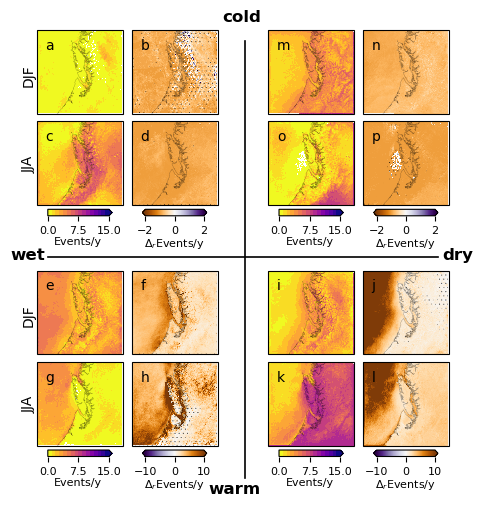

In [12]:
import matplotlib.gridspec as gridspec
dense_dots = "." * 2  # repeat the dot
hatches = [dense_dots + " " + dense_dots]

row_labels = ["DJF", "JJA"]
nrows = 4
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

at=0.1;bt=0.9
#vvals={'coldwet': 25, 'warmwet':25, 'warmdry': 25, 'colddry':25}
vvals={'coldwet': 2, 'warmwet':10, 'warmdry': 10, 'colddry':2}
labels=['count', r'$\Delta\, \mathrm{count}$']
cmaps={'coldwet': 'PuOr', 'warmwet':'PuOr_r', 'warmdry': 'PuOr_r', 'colddry':'PuOr'}

fig = plt.figure(figsize=(5.4,5.4))

gs = gridspec.GridSpec(
    5, 5, figure=fig,
    height_ratios=[1, 1, 0.6, 1, 1],   # colorbar row is short
    width_ratios=[1, 1, 0.43, 1, 1],    # middle spacer col is narrow
    hspace=0.1, wspace=0.025
)

axes = np.empty((4,4), dtype=object)

# Fill rows 0 and 1 (top half)
for i in range(2):
    for j in range(2):  # left block
        axes[i,j] = fig.add_subplot(gs[i, j], projection=wpsproj)
    for j in range(2,4):  # right block
        axes[i,j] = fig.add_subplot(gs[i, j+1], projection=wpsproj)

# Fill rows 3 and 4 (bottom half)
for i in range(2):
    for j in range(2):  # left block
        axes[i+2,j] = fig.add_subplot(gs[i+3, j], projection=wpsproj)
    for j in range(2,4):  # right block
        axes[i+2,j] = fig.add_subplot(gs[i+3, j+1], projection=wpsproj)

count=0
for i in range(2):          # seasons: JJA, DJF
    for j in range(2):
        ax = axes[i, j]   # careful indexing
        countmax=15
        var='coldwet'
        data = eval(var)
        val=vvals[var];

        if j==0: #upper left
            ax.text(-0.18, 0.6, row_labels[i], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #print(val)
        count=plotdata(data, val,count, var)
        #plotdata(data, val)
        var='warmwet'
        ax=axes[i+2,j]
        count=plotdata(data, val,count, var)
        if j==0:
            ax.text(-0.18, 0.6, row_labels[i], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')        
        countmax=15
        var='warmdry'
        
        ax=axes[i+2,j+2]
        #plotdata(data, val)
        count=plotdata(data, val,count, var)
        var='colddry'
        ax=axes[i,j+2]
        count=plotdata(data, val,count, var)


# Vertical divider: between left and right panels
# --- Top half vertical divider ---
x_div = axes[0,1].get_position().x1 +0.05  # right edge of left block

y1_top = axes[0,0].get_position().y1 # top of row 0 (first row)


# --- Bottom half vertical divider ---
y0_bot = 0#axes[3,0].get_position().y0  # bottom of row 3


fig.add_artist(plt.Line2D([x_div, x_div], [y0_bot+0.05, y1_top-0.02],
                          transform=fig.transFigure, color="black", lw=1.2))
# Horizontal divider: between top and bottom panels
# Take x-limits from the leftmost and rightmost panels in that row
x0 = axes[0,0].get_position().x0   # left edge of far-left panel
x1 = axes[0,3].get_position().x1   # right edge of far-right panel
y_div = axes[2,0].get_position().y1+0.025 # top of bottom block
fig.add_artist(plt.Line2D([x0+0.02, x1-0.02], [y_div, y_div],
                          transform=fig.transFigure, color="black", lw=1.2))

# Cold label (left of vertical line, top)
fig.text(x_div+0.03 , y1_top+0.01, "cold", ha="right", va="bottom", fontsize=12, fontweight="bold")
# Warm label (right of vertical line, bottom)
fig.text(x_div+0.03 , y0_bot+0.015, "warm", ha="right", va="bottom", fontsize=12, fontweight="bold")


# Wet label (left of horizontal line, top)
fig.text(x0-0.05, y_div-0.01 , "wet", ha="left", va="bottom", fontsize=12, fontweight="bold")
# Dry label (right of horizontal line, bottom)
fig.text(x1+0.045, y_div-0.01, "dry", ha="right", va="bottom", fontsize=12, fontweight="bold")
plt.savefig('../Figures/CompoundEvents_lte_mult.png', format='png', bbox_inches='tight',transparent=False,dpi=500)

/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDepr

var,f,h,f-h, f-h/h 0.45354166666666673 coldwet 1.8966037565875409 -1.4369538534300257 -0.7608664091846468
var,f,h,f-h, f-h/h 9.274523333333333 warmwet 2.2929879284716903 7.106443403450295 3.044732734164431
var,f,h,f-h, f-h/h 16.26137833333333 warmdry 4.879081111111111 11.382297222222222 2.332877228931768
var,f,h,f-h, f-h/h 0.30981888888888887 colddry 1.780962222222222 -1.4711433333333332 -0.8260384835663116


/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1231/ipykernel_1433/1903892627.py:24: MatplotlibDepr

var,f,h,f-h, f-h/h 0.1720422222222222 coldwet 1.6760496204698512 -1.501672410297993 -0.8973525484442437
var,f,h,f-h, f-h/h 11.651748888888887 warmwet 2.311232728624033 9.497568775829643 4.041356824254401
var,f,h,f-h, f-h/h 15.066641666666664 warmdry 4.330906666666667 10.735734999999998 2.478865472356827
var,f,h,f-h, f-h/h 0.46270833333333333 colddry 2.485400555555555 -2.022692222222222 -0.813829472155282


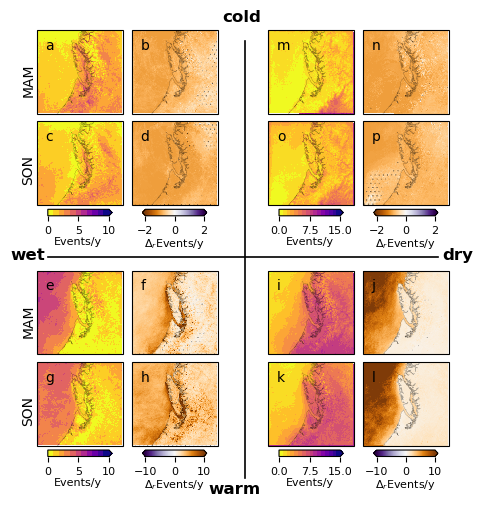

In [13]:
import matplotlib.gridspec as gridspec
dense_dots = "." * 2  # repeat the dot
hatches = [dense_dots + " " + dense_dots]

row_labels = ["MAM", "SON"]
nrows = 4
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

at=0.1;bt=0.9
#vvals={'coldwet': 5, 'warmwet':50, 'warmdry': 50, 'colddry':5}
labels=['count', r'$\Delta\, \mathrm{count}$']
cmaps={'coldwet': 'PuOr', 'warmwet':'PuOr_r', 'warmdry': 'PuOr_r', 'colddry':'PuOr'}

fig = plt.figure(figsize=(5.4,5.4))

gs = gridspec.GridSpec(
    5, 5, figure=fig,
    height_ratios=[1, 1, 0.6, 1, 1],   # colorbar row is short
    width_ratios=[1, 1, 0.43, 1, 1],    # middle spacer col is narrow
    hspace=0.1, wspace=0.025
)

axes = np.empty((4,4), dtype=object)

# Fill rows 0 and 1 (top half)
for i in range(2):
    for j in range(2):  # left block
        axes[i,j] = fig.add_subplot(gs[i, j], projection=wpsproj)
    for j in range(2,4):  # right block
        axes[i,j] = fig.add_subplot(gs[i, j+1], projection=wpsproj)

# Fill rows 3 and 4 (bottom half)
for i in range(2):
    for j in range(2):  # left block
        axes[i+2,j] = fig.add_subplot(gs[i+3, j], projection=wpsproj)
    for j in range(2,4):  # right block
        axes[i+2,j] = fig.add_subplot(gs[i+3, j+1], projection=wpsproj)

count=0
for i in range(2):          # seasons: JJA, DJF
    for j in range(2):
        ax = axes[i, j]   # careful indexing
        countmax=10
        var='coldwet'
        data = eval(var)
        val=vvals[var];

        if j==0: #upper left
            ax.text(-0.18, 0.6, row_labels[i], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #print(val)
        count=plotdata(data, val,count, var)
        #plotdata(data, val)
        var='warmwet'
        ax=axes[i+2,j]
        count=plotdata(data, val,count, var)
        if j==0:
            ax.text(-0.18, 0.6, row_labels[i], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')        
        countmax=15
        var='warmdry'
        
        ax=axes[i+2,j+2]
        #plotdata(data, val)
        count=plotdata(data, val,count, var)
        var='colddry'
        ax=axes[i,j+2]
        count=plotdata(data, val,count, var)


# Vertical divider: between left and right panels
# --- Top half vertical divider ---
x_div = axes[0,1].get_position().x1 +0.05  # right edge of left block

y1_top = axes[0,0].get_position().y1 # top of row 0 (first row)


# --- Bottom half vertical divider ---
y0_bot = 0#axes[3,0].get_position().y0  # bottom of row 3


fig.add_artist(plt.Line2D([x_div, x_div], [y0_bot+0.05, y1_top-0.02],
                          transform=fig.transFigure, color="black", lw=1.2))
# Horizontal divider: between top and bottom panels
# Take x-limits from the leftmost and rightmost panels in that row
x0 = axes[0,0].get_position().x0   # left edge of far-left panel
x1 = axes[0,3].get_position().x1   # right edge of far-right panel
y_div = axes[2,0].get_position().y1+0.025 # top of bottom block
fig.add_artist(plt.Line2D([x0+0.02, x1-0.02], [y_div, y_div],
                          transform=fig.transFigure, color="black", lw=1.2))

# Cold label (left of vertical line, top)
fig.text(x_div+0.03 , y1_top+0.01, "cold", ha="right", va="bottom", fontsize=12, fontweight="bold")
# Warm label (right of vertical line, bottom)
fig.text(x_div+0.03 , y0_bot+0.015, "warm", ha="right", va="bottom", fontsize=12, fontweight="bold")


# Wet label (left of horizontal line, top)
fig.text(x0-0.05, y_div-0.01 , "wet", ha="left", va="bottom", fontsize=12, fontweight="bold")
# Dry label (right of horizontal line, bottom)
fig.text(x1+0.045, y_div-0.01, "dry", ha="right", va="bottom", fontsize=12, fontweight="bold")
plt.savefig('../Figures/CompoundEvents_FS_lte_mult.png', format='png', bbox_inches='tight',transparent=False,dpi=500)

In [14]:
domain='d03'
geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  
basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
gridded_data_path = basepath+'historical/variables_complete/'


# --------------------------------------------------------
# Land mask
# --------------------------------------------------------

landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()

landmask = landmask.rename({
    'south_north': 'lat',
    'west_east': 'lon'
})
print('dimensions on landmask', landmask.T.dims)
landmask = landmask.values

land_mask  = (landmask == 1)
ocean_mask = (landmask == 0)

dimensions on landmask ('lon', 'lat')


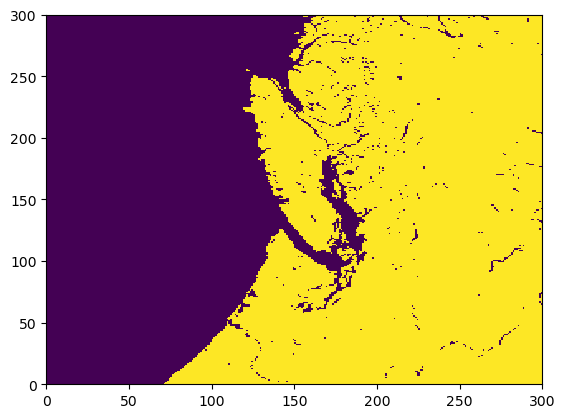

In [15]:
plt.pcolormesh(land_mask)

In [16]:
import numpy as np
import pandas as pd

# --------------------------------------------------------
# Helper: masked mean
# --------------------------------------------------------
def masked_mean(field, mask):
    """
    field : 2D array (lat, lon)
    mask  : boolean array (same shape)

    returns spatial mean ignoring NaNs
    """
    field = np.asarray(field)

    if field.shape != mask.shape:
        raise ValueError(
            f"Shape mismatch: field {field.shape}, mask {mask.shape}"
        )

    return np.nanmean(field[mask])
def masked_max(field, mask):
    """
    field : 2D array (lat, lon)
    mask  : boolean array (same shape)

    returns spatial mean ignoring NaNs
    """
    field = np.asarray(field)

    if field.shape != mask.shape:
        raise ValueError(
            f"Shape mismatch: field {field.shape}, mask {mask.shape}"
        )

    return np.nanmax(field[mask])

# --------------------------------------------------------
# Compute land/ocean averages
# --------------------------------------------------------
results = []

field_names = ['coldwet', 'warmwet', 'warmdry', 'colddry']

for season in  ['DJF', 'JJA', 'MAM', 'SON']:

    for var in field_names:
        data = eval(var)
  
        # assuming variables are dictionaries indexed by season
        # adjust this line to match your structure
        # Compute same field shown in plot
        field = (
            data['F_' + season] -
            data[season]
        ) / data[season]
        
        land_avg = masked_mean(field, land_mask)
        ocean_avg = masked_mean(field, ocean_mask)
        land_max = masked_max(field, land_mask)
        ocean_max = masked_max(field, ocean_mask)
        results.append({
            'season': season,
            'field': var,
            'land_mean': land_avg,
            'ocean_mean': ocean_avg,
            'land_max': land_max,
            'ocean_max': ocean_max
        })

summary = pd.DataFrame(results)

print(summary)

summary.to_csv(
    '../Figures/compound_event_land_ocean_means.csv',
    index=False
)

   season    field  land_mean  ocean_mean   land_max   ocean_max
0     DJF  coldwet  -0.677518   -0.885786   4.000000    1.800000
1     DJF  warmwet   2.211697    4.597681   8.230769   23.800000
2     DJF  warmdry   1.129252    9.605621   5.666667   49.800000
3     DJF  colddry  -0.729687   -0.859734  -0.318182   -0.230769
4     JJA  coldwet  -0.906111   -0.956003  -0.661017   -0.378788
5     JJA  warmwet   3.407530    5.973336  81.000000  233.000000
6     JJA  warmdry   2.538843    7.490009   8.911765   28.384615
7     JJA  colddry  -0.958993   -0.982776  -0.333333    0.132353
8     MAM  coldwet  -0.684370   -0.928750   0.500000    0.135135
9     MAM  warmwet   2.023261    3.913695  15.500000   37.000000
10    MAM  warmdry   1.058826    6.802665   5.816327   18.266667
11    MAM  colddry  -0.792648   -0.946117   0.058824   -0.160000
12    SON  coldwet  -0.861672   -0.950754   0.000000    0.590909
13    SON  warmwet   3.284667    4.918497  18.000000   24.600000
14    SON  warmdry   1.16

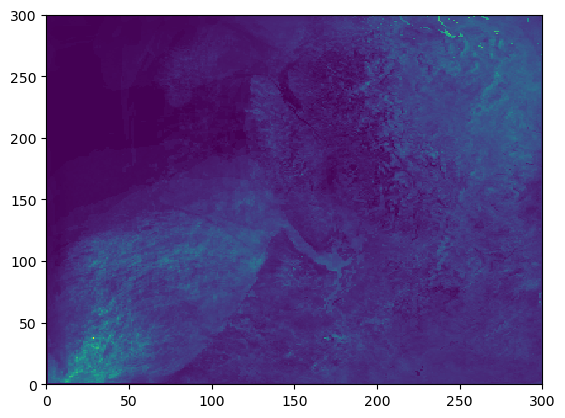

In [17]:
plt.pcolormesh(field)
#plt.contourf(land_mask.T, levels=[0,0.01])

In [18]:

# Average across seasons
summary_all = (
    summary
    .groupby("field", as_index=False)
    .agg(
        land_mean_avg=("land_mean", "mean"),
        ocean_mean_avg=("ocean_mean", "mean"),
        land_max_avg=("land_max", "mean"),
        ocean_max_avg=("ocean_max", "mean"),
    )
)

print(summary_all)

     field  land_mean_avg  ocean_mean_avg  land_max_avg  ocean_max_avg
0  colddry      -0.814705       -0.905881     -0.210673       0.060396
1  coldwet      -0.782418       -0.930323      0.959746       0.536814
2  warmdry       1.472695        7.987200      6.115356      29.716987
3  warmwet       2.731789        4.850802     30.682692      79.600000


In [19]:
summary_compare = (
    summary
    .groupby("field", as_index=False)
    .agg(
        land=("land_mean", "mean"),
        ocean=("ocean_mean", "mean"),
    )
)

summary_compare["ocean_minus_land"] = (
    summary_compare["ocean"] - summary_compare["land"]
)

display(summary_compare)

,field,land,ocean,ocean_minus_land
0,colddry,-0.814705,-0.905881,-0.091175
1,coldwet,-0.782418,-0.930323,-0.147906
2,warmdry,1.472695,7.987200,6.514505
3,warmwet,2.731789,4.850802,2.119013


In [20]:
import pandas as pd
import numpy as np

# Copy to avoid modifying original
tmp = summary.copy()

# Collapse event types
tmp["temp_group"] = np.where(
    tmp["field"].str.startswith("cold"),
    "cold",
    "warm"
)

# Average across seasons and wet/dry subclasses
summary_temp = (
    tmp
    .groupby("temp_group", as_index=False)
    .agg(
        land_mean=("land_mean", "mean"),
        ocean_mean=("ocean_mean", "mean"),
        land_max=("land_max", "mean"),
        ocean_max=("ocean_max", "mean"),
    )
)



display(summary_temp)

,temp_group,land_mean,ocean_mean,land_max,ocean_max
0,cold,-0.798561,-0.918102,0.374536,0.298605
1,warm,2.102242,6.419001,18.399024,54.658494


In [21]:
avgs=(summary_temp['land_mean']+summary_temp['ocean_mean'])/2.0
print('cold_avg', avgs[0])
print('warm_avg', avgs[1])

cold_avg -0.8583316144584419
warm_avg 4.260621397573579


In [22]:
import numpy as np
import pandas as pd

# --------------------------------------------------------
# Compute three different summary statistics per field/season/region:
#   1. mean_of_ratios : current approach -> mean( (F_i - H_i)/H_i ) over grid cells i
#   2. ratio_of_means : (mean(F_i) - mean(H_i)) / mean(H_i)  -- pooled/aggregate rate ratio
#   3. median_of_ratios + IQR : robust "typical grid cell" statistic
# --------------------------------------------------------

def masked_stats(F, H, mask):
    """
    F, H : 2D arrays (future counts, historical counts), same shape
    mask : boolean array, same shape (e.g. land_mask or ocean_mask)

    Returns dict with mean_of_ratios, ratio_of_means, median_of_ratios,
    p25_of_ratios, p75_of_ratios, n_cells_used
    """
    F = np.asarray(F)[mask]
    H = np.asarray(H)[mask]

    # Guard against H == 0 (undefined ratio) -- exclude those cells explicitly
    # rather than letting them silently produce inf/nan in the ratio field.
    valid = H > 0
    F_valid = F[valid]
    H_valid = H[valid]

    ratios = (F_valid - H_valid) / H_valid

    mean_of_ratios = np.nanmean(ratios)
    ratio_of_means = (np.nanmean(F_valid) - np.nanmean(H_valid)) / np.nanmean(H_valid)
    median_of_ratios = np.nanmedian(ratios)
    p25 = np.nanpercentile(ratios, 25)
    p75 = np.nanpercentile(ratios, 75)

    return {
        'mean_of_ratios': mean_of_ratios,
        'ratio_of_means': ratio_of_means,
        'median_of_ratios': median_of_ratios,
        'p25_of_ratios': p25,
        'p75_of_ratios': p75,
        'n_cells_excluded_H0': int((~valid).sum()),
        'n_cells_used': int(valid.sum()),
    }


# --------------------------------------------------------
# Build comparison table across all fields/seasons/regions
# --------------------------------------------------------
results = []
field_names = ['coldwet', 'warmwet', 'warmdry', 'colddry']

for season in ['DJF', 'JJA', 'MAM', 'SON']:
    for var in field_names:
        data = eval(var)
        F = data['F_' + season]
        H = data[season]

        for region_name, mask in [('land', land_mask), ('ocean', ocean_mask)]:
            stats = masked_stats(F, H, mask)
            stats.update({'season': season, 'field': var, 'region': region_name})
            results.append(stats)

comparison = pd.DataFrame(results)

# Reorder columns for readability
cols = ['season', 'field', 'region', 'mean_of_ratios', 'ratio_of_means',
        'median_of_ratios', 'p25_of_ratios', 'p75_of_ratios',
        'n_cells_used', 'n_cells_excluded_H0']
comparison = comparison[cols]

print(comparison.to_string(index=False))

comparison.to_csv('../Figures/compound_event_stats_comparison.csv', index=False)

# --------------------------------------------------------
# Collapse to warm/cold groups, averaged across seasons and wet/dry,
# for the three candidate headline statistics
# --------------------------------------------------------
comparison['temp_group'] = np.where(
    comparison['field'].str.startswith('cold'), 'cold', 'warm'
)

headline = (
    comparison
    .groupby(['temp_group', 'region'], as_index=False)
    .agg(
        mean_of_ratios=('mean_of_ratios', 'mean'),
        ratio_of_means=('ratio_of_means', 'mean'),
        median_of_ratios=('median_of_ratios', 'mean'),
        p25=('p25_of_ratios', 'mean'),
        p75=('p75_of_ratios', 'mean'),
    )
)

print("\n--- Headline warm/cold, land/ocean comparison ---")
print(headline.to_string(index=False))

# Land+ocean combined (average of the two regions), matching current
# manuscript convention of averaging land_mean and ocean_mean
headline_combined = (
    headline
    .groupby('temp_group', as_index=False)
    .agg(
        mean_of_ratios=('mean_of_ratios', 'mean'),
        ratio_of_means=('ratio_of_means', 'mean'),
        median_of_ratios=('median_of_ratios', 'mean'),
        p25=('p25', 'mean'),
        p75=('p75', 'mean'),
    )
)

print("\n--- Combined (land+ocean averaged) warm/cold ---")
print(headline_combined.to_string(index=False))

season   field region  mean_of_ratios  ratio_of_means  median_of_ratios  p25_of_ratios  p75_of_ratios  n_cells_used  n_cells_excluded_H0
   DJF coldwet   land       -0.677518       -0.702775         -0.750000      -0.888889      -0.571429         46856                 2125
   DJF coldwet  ocean       -0.885786       -0.892083         -0.900000      -0.937500      -0.846154         40466                  553
   DJF warmwet   land        2.211697        2.049351          2.013699       1.605263       2.673077         48338                  643
   DJF warmwet  ocean        4.597681        4.321785          4.313953       3.774194       5.146667         40466                  553
   DJF warmdry   land        1.129252        1.084695          1.084337       0.822581       1.380000         48981                    0
   DJF warmdry  ocean        9.605621        6.115739          9.214286       3.982456      13.727273         41019                    0
   DJF colddry   land       -0.729687    